In [ ]:
-import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

from xgboost import XGBClassifier
from scipy.stats import mode

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

folder_path = "/content/drive/MyDrive/mimic_dataset"

files = os.listdir(folder_path)
print("Files in folder:")
print(files)

Files in folder:
['ADMISSIONS.csv', 'D_LABITEMS.csv', 'structured_medical_records.csv', 'LABEVENTS.csv', 'PATIENTS.csv']


In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import pandas as pd

file_path = os.path.join("/content/drive/MyDrive/mimic_dataset", "ADMISSIONS.csv")
data = pd.read_csv(file_path)

print("Dataset Shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nFirst 5 rows:")
print(data.head())

Dataset Shape: (129, 19)

Columns:
Index(['row_id', 'subject_id', 'hadm_id', 'admittime', 'dischtime',
       'deathtime', 'admission_type', 'admission_location',
       'discharge_location', 'insurance', 'language', 'religion',
       'marital_status', 'ethnicity', 'edregtime', 'edouttime', 'diagnosis',
       'hospital_expire_flag', 'has_chartevents_data'],
      dtype='object')

First 5 rows:
   row_id  subject_id  hadm_id            admittime            dischtime  \
0   12258       10006   142345  2164-10-23 21:09:00  2164-11-01 17:15:00   
1   12263       10011   105331  2126-08-14 22:32:00  2126-08-28 18:59:00   
2   12265       10013   165520  2125-10-04 23:36:00  2125-10-07 15:13:00   
3   12269       10017   199207  2149-05-26 17:19:00  2149-06-03 18:42:00   
4   12270       10019   177759  2163-05-14 20:43:00  2163-05-15 12:00:00   

             deathtime admission_type         admission_location  \
0                  NaN      EMERGENCY       EMERGENCY ROOM ADMIT   
1  2126-

In [ ]:
# Handle missing values
data = data.ffill().bfill()

# Drop useless ID columns
data = data.drop(columns=[
    "row_id",
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "deathtime",
    "edregtime",
    "edouttime"
])

# Set target
target_column = "hospital_expire_flag"

# Separate X and y
X = data.drop(columns=[target_column])
y = data[target_column]

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    max_iter=300,
    random_state=42
)

mlp.fit(X_train, y_train)

print("MLP Parameters:")
print(mlp.get_params())

MLP Parameters:
{'activation': 'relu', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 300, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    max_depth=6,
    learning_rate=0.05,
    n_estimators=200,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

print("XGBoost Parameters:")
print(xgb.get_params())

XGBoost Parameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [ ]:
import numpy as np
from scipy.stats import mode

PMLP = mlp.predict(X_test)
PXGB = xgb.predict(X_test)

combined = np.vstack((PMLP, PXGB))
Pfinal = mode(combined, axis=0)[0].flatten()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n{name} Results")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    return acc, prec, rec, f1


mlp_metrics = evaluate_model("MLP", y_test, PMLP)
xgb_metrics = evaluate_model("XGBoost", y_test, PXGB)
mxboost_metrics = evaluate_model("MXBoost", y_test, Pfinal)


MLP Results
Accuracy: 0.9230769230769231
Precision: 0.95
Recall: 0.875
F1 Score: 0.9022556390977443

XGBoost Results
Accuracy: 0.9615384615384616
Precision: 0.9444444444444444
Recall: 0.9722222222222222
F1 Score: 0.9563025210084033

MXBoost Results
Accuracy: 0.9230769230769231
Precision: 0.95
Recall: 0.875
F1 Score: 0.9022556390977443


In [ ]:
average='macro'

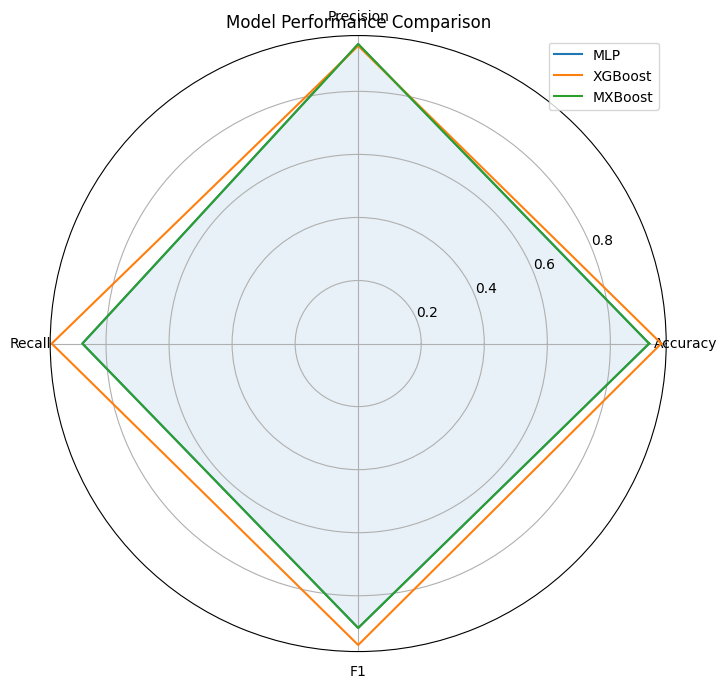

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Accuracy', 'Precision', 'Recall', 'F1']

mlp_values = list(mlp_metrics)
xgb_values = list(xgb_metrics)
mxboost_values = list(mxboost_metrics)

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

mlp_values += mlp_values[:1]
xgb_values += xgb_values[:1]
mxboost_values += mxboost_values[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

ax.plot(angles, mlp_values, label='MLP')
ax.plot(angles, xgb_values, label='XGBoost')
ax.plot(angles, mxboost_values, label='MXBoost')

ax.fill(angles, mxboost_values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.legend()
plt.title("Model Performance Comparison")
plt.show()

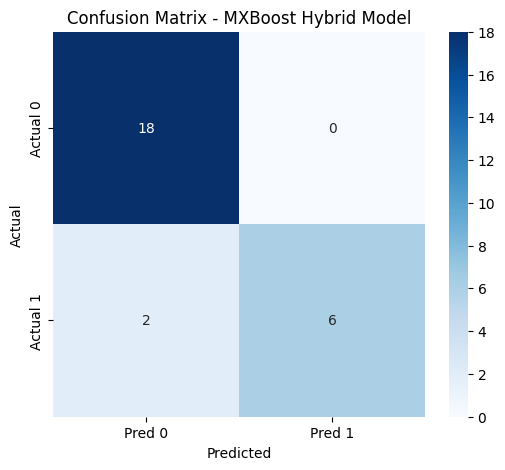

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, Pfinal)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['Actual 0','Actual 1'])

plt.title("Confusion Matrix - MXBoost Hybrid Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro'),
        recall_score(y_true, y_pred, average='macro'),
        f1_score(y_true, y_pred, average='macro')
    ]

mlp_metrics = get_metrics(y_test, PMLP)
xgb_metrics = get_metrics(y_test, PXGB)
mxboost_metrics = get_metrics(y_test, Pfinal)

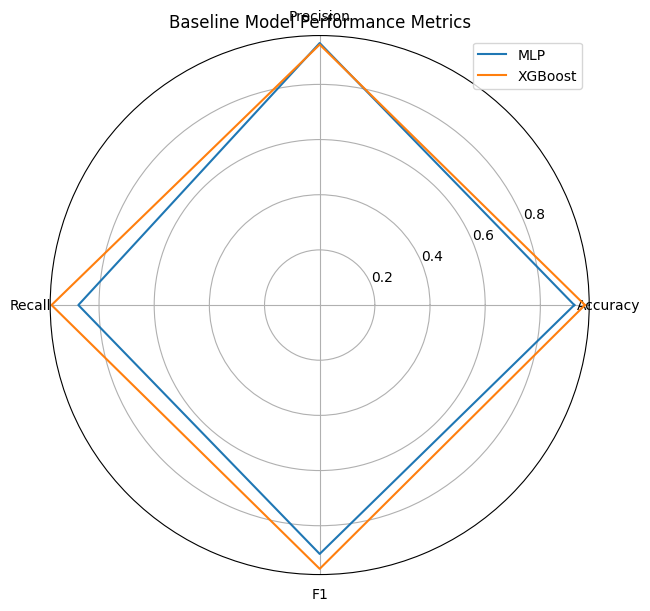

In [ ]:
import numpy as np

labels = ['Accuracy','Precision','Recall','F1']
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

mlp_values = mlp_metrics + mlp_metrics[:1]
xgb_values = xgb_metrics + xgb_metrics[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

ax.plot(angles, mlp_values, label='MLP')
ax.plot(angles, xgb_values, label='XGBoost')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Baseline Model Performance Metrics")
plt.legend()
plt.show()

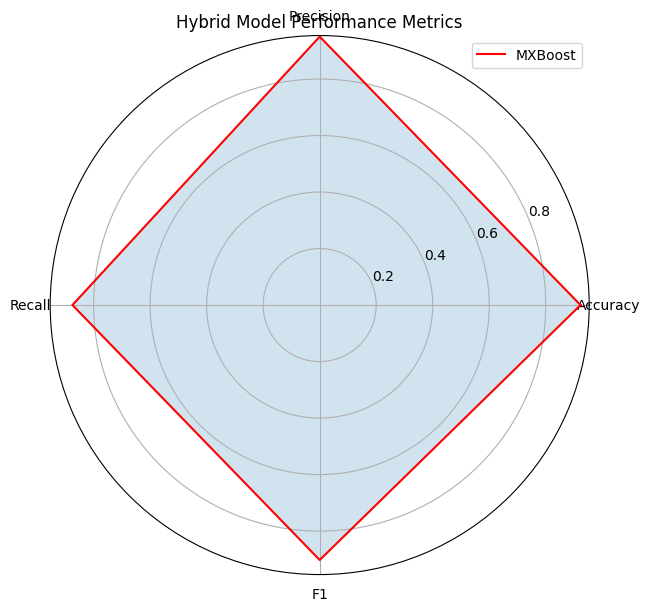

In [ ]:
mxboost_values = mxboost_metrics + mxboost_metrics[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

ax.plot(angles, mxboost_values, label='MXBoost', color='red')
ax.fill(angles, mxboost_values, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Hybrid Model Performance Metrics")
plt.legend()
plt.show()

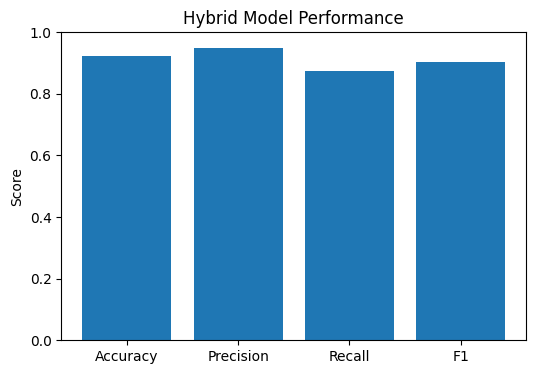

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(labels, mxboost_metrics)

plt.title("Hybrid Model Performance")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()